In [54]:
import sys
sys.path.append('/Users/chonge/Documents/Document/University_of_Chicago/transaction_project')
from models import MF, FM, DeepFM, RecSys

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import datetime as dt
import math
import random 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchmetrics.regression import MeanSquaredError
from sklearn.metrics import precision_score, recall_score
from torch import nn
from torchsummary import summary
from torchviz import make_dot
import torch.nn.functional as F
from itertools import product

In [56]:
# %load_ext tensorboard
%matplotlib inline
sbn.set_style("whitegrid")

In [57]:
# set seed
seed = 107
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [58]:
model_path = '/Users/chonge/Documents/Document/University_of_Chicago/transaction_project/models/quantity_pred'

In [59]:
# key hyperparameters
num_features = 38
batch_size = 16

### Load the data 

In [60]:
user_item_table = pd.read_csv('../final_data/user_item_table.csv')
user_item_table.head(1)

,customer_id,product_id,quantity,price,day,online_order,gender,num_prev_purchase,age,owns_car,...,product_line_Road,product_line_Standard,product_line_Touring,product_class_high,product_class_low,product_class_medium,product_size_large,product_size_medium,product_size_small,target
0,0,0,0.0,0.0,0.0,0,0,0.939394,0.685714,0,...,1,0,0,0,0,1,0,1,0,0


In [61]:
user_item_table.quantity.value_counts()

0.0    326224
1.0     17493
2.0       729
3.0       116
4.0        36
5.0        14
Name: quantity, dtype: int64

### Train-test split and Pytorch Dataloader

In [62]:
class transactionDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.df = df
        self.users = df.customer_id.to_numpy()
        self.items = df.product_id.to_numpy()
        self.price = df.price_norm.to_numpy()
        self.gender = df.gender.to_numpy()
        self.owns_car = df.owns_car.to_numpy()
        self.online_order = df.online_order.to_numpy()
        self.age = df.age.to_numpy()
        self.prev_purchase = df.num_prev_purchase.to_numpy()
        self.cat_features = df[df.columns[13:]].to_numpy()
        self.target = df.quantity.to_numpy()
        self.dense_features = df[['price','age','num_prev_purchase','gender','owns_car','online_order']].to_numpy()

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.dense_features[idx], self.users[idx], self.items[idx], self.cat_features[idx],self.target[idx]

    def print_sample(self, idx=0):
        return {'customer_id': self.users[idx], 
                'product_id': self.items[idx], 
                'target': self.target[idx],
                'quantity': self.quantity[idx],
                'price': self.price[idx],
                'gender': self.gender[idx],
                'owns_car': self.owns_car[idx],
                'online_order': self.online_order[idx],
                'age': self.age[idx],
                'prev_purchase': self.prev_purchase[idx],
                'cat_features': self.cat_features[idx]
               }
    
    def get_Dataset(self):
        return self.df

    def get_num_user(self):
        return len(np.unique(self.users))
    
    def get_num_item(self):
        return len(np.unique(self.items))

In [63]:
def train_tet_val_split(data):
    train, test = train_test_split(data, test_size=0.20, random_state=107)
    test, val = train_test_split(test, test_size=0.33, random_state=107)
    return transactionDataset(train), transactionDataset(test), transactionDataset(val)

In [64]:
train_bi, test_bi, val_bi = train_tet_val_split(user_item_table)

In [65]:
np.unique(train_bi.target, return_counts=True)

(array([0., 1., 2., 3., 4., 5.]),
 array([260990,  13971,    591,     99,     26,     12]))

In [66]:
np.unique(test_bi.target, return_counts=True)

(array([0., 1., 2., 3., 4., 5.]),
 array([43767,  2307,    85,    11,     7,     1]))

In [67]:
np.unique(val_bi.target, return_counts=True)

(array([0., 1., 2., 3., 4., 5.]),
 array([21467,  1215,    53,     6,     3,     1]))

In [68]:
train_loader_bi = DataLoader(dataset=train_bi, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader_bi = DataLoader(dataset=test_bi, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader_bi = DataLoader(dataset=val_bi, batch_size=batch_size, shuffle=True, drop_last=True)

### Modeling

In [69]:
torch.set_default_dtype(torch. float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [70]:
rcsys = RecSys(num_users=train_bi.get_num_user(), num_items=train_bi.get_num_item(), emb_size=8, deep_param=[128,64,32], num_features=num_features)

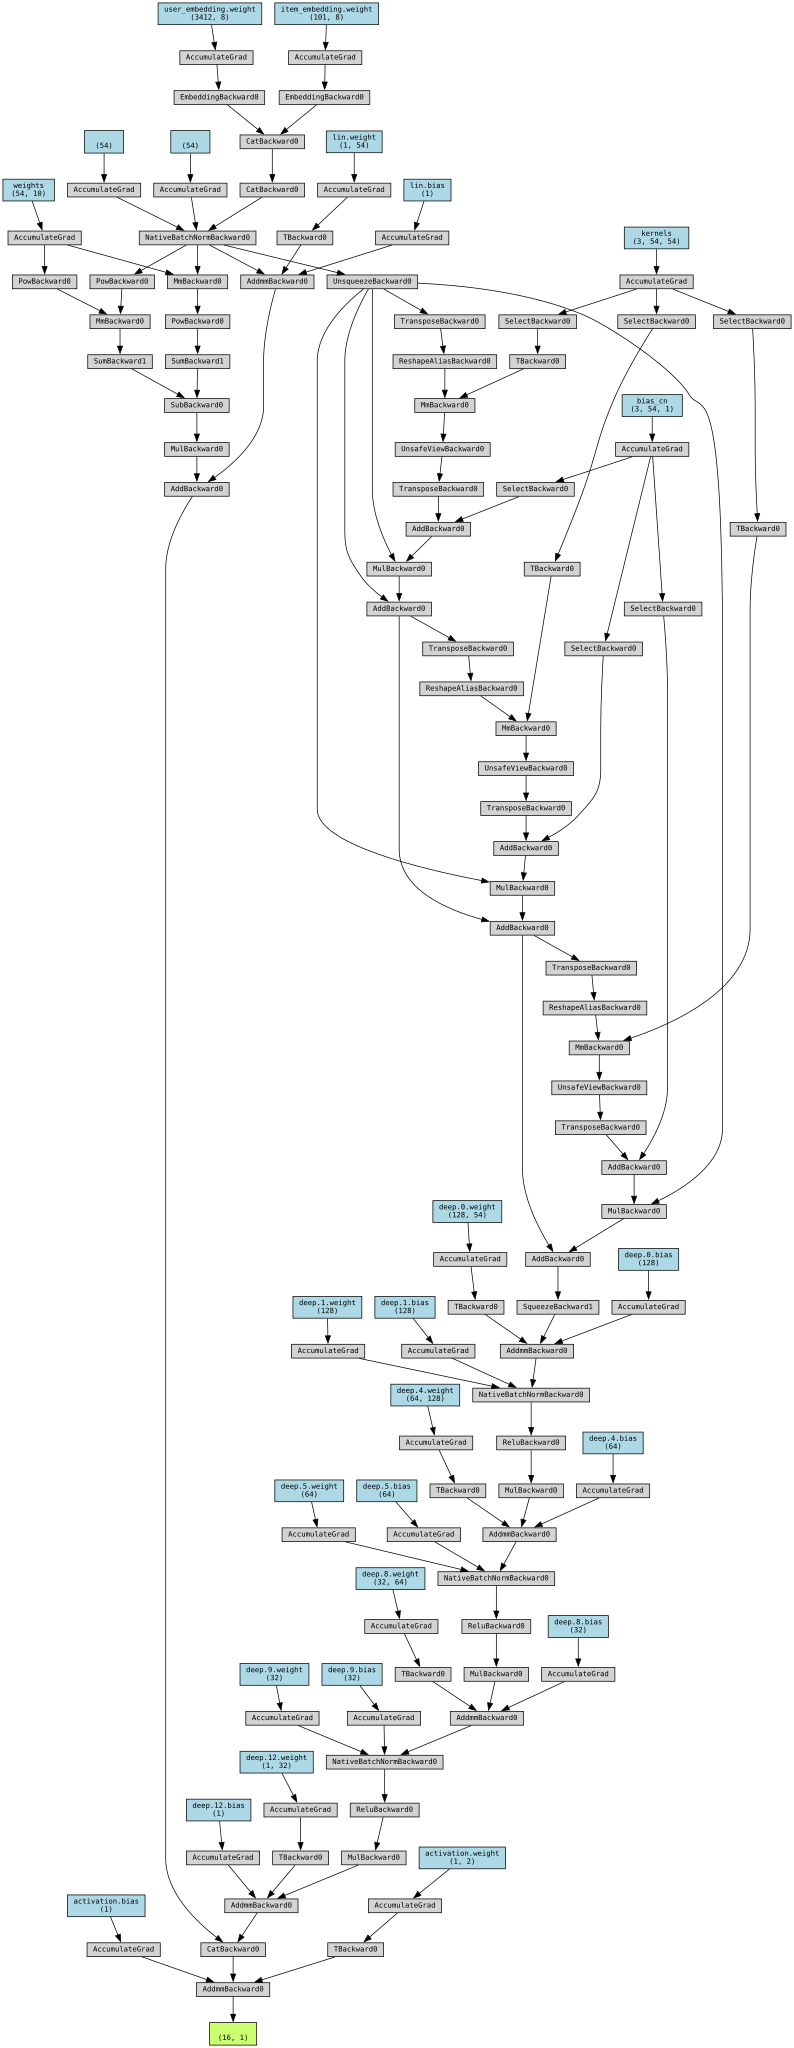

In [71]:
yhat = rcsys(*next(iter(train_loader_bi))[:-1])
make_dot(yhat, params=dict(list(rcsys.named_parameters())))

In [72]:
def trainModel(epochs, model, loss_func, trainloader, testloader, optimizer, patience, 
               save_model = True, save_model_name = 'best_model',
               scheduler=None, clip_threshold=1.0, recallatKinputs=None):
    train_loss_lst = []
    train_loss = 0
    test_loss_lst = []
    test_loss = 0
    e = 0
    best_test_loss = 10000000
    best_epoch = 0
    earlystop = False
    print('---------Start Training---------')
    while e < epochs | earlystop:
        # train
        model.train()
        for i, train_batch in enumerate(trainloader):
            optimizer.zero_grad()
            predict = model(*train_batch[:-1]).to(torch.float64)
            if predict.isnan().sum().item() > 0:
                print('NAN')
            actual = torch.unsqueeze(train_batch[-1],1).to(torch.float64)
            loss = loss_func(predict, actual)
            train_loss += loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_threshold)
            optimizer.step()
        train_loss /= len(trainloader)
        train_loss_lst.append(train_loss.item())
        
        # evaluate
        with torch.no_grad():
            model.eval()
            prediction = []
            target = []
            for test_batch in testloader:
                predict = model(*test_batch[:-1]).to(torch.float64)
                if predict.isnan().sum().item() > 0:
                    print('NAN FOUND')
                actual = torch.unsqueeze(test_batch[-1],1)
                loss = loss_func(predict, actual.to(torch.float64))
                test_loss += loss
            test_loss /= len(testloader)
            test_loss_lst.append(test_loss.item())
        
        print('Epoch:', e, 'Train loss:', train_loss.item(), 'Test loss:', test_loss.item())
        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()
            best_epoch = e
            if save_model:
                torch.save({
                    'optimizer': optimizer.state_dict(),
                    'model': model.state_dict(),
                    'epoch': e
                }, model_path+'/'+save_model_name+'.pth')        
        elif e - best_epoch > patience:
            print("Early stopped training at epoch %d" %e + ', with the best epoch at %d' %best_epoch)
            print('The best test loss is ' + str(best_test_loss))
            break  
        print('--------------------------------------')
        if recallatKinputs != None:
            print('Recall@10: ', recallAtK(model,recallatKinputs['current'],recallatKinputs['future'],recallatKinputs['k']))
            print('Precision@10: ', precisionAtK(model,recallatKinputs['current'],recallatKinputs['future'],recallatKinputs['k']))
            print('--------------------------------------')


        if scheduler:
            scheduler.step()
        train_loss = 0
        test_loss = 0
        e += 1
        
    return train_loss_lst, test_loss_lst

In [73]:
def evalModel(model, evaldata):
    with torch.no_grad():
        model.eval()
        for test_batch in evaldata:
            predict = model(*test_batch[:-1]).to(torch.float64)
            if predict.isnan().sum().item() > 0:
                print('NAN FOUND')
            actual = torch.unsqueeze(test_batch[-1],1)
            loss = loss_func(predict, actual.to(torch.float64))
            test_loss += loss
        test_loss /= len(testloader)
        return {
            'RMSE': test_loss,
            'MSE': test_loss**2
        }

In [74]:
class RMSELoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps
        
    def forward(self,yhat,y):
        loss = torch.sqrt(self.mse(yhat,y) + self.eps)
        return loss

In [75]:
# some hyperparamters 
num_epoch = 1000
num_user = len(np.unique(user_item_table.customer_id))
num_item = len(np.unique(user_item_table.product_id))

In [24]:
# MF train
mf = MF(num_users=num_user, num_items=num_item, emb_size=64, num_features=num_features)
optimizer = torch.optim.Adam(mf.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = RMSELoss()
mf_train_loss_list, mf_test_loss_list = trainModel(
    num_epoch, mf, loss_function, train_loader_bi, test_loader_bi, 
    optimizer, patience=3, clip_threshold=0.2, save_model=False)

---------Start Training---------
Epoch: 0 Train loss: 5.47982148753651 Test loss: 3.6700688424466725
--------------------------------------
Epoch: 1 Train loss: 2.593107947341347 Test loss: 1.722039535920754
--------------------------------------
Epoch: 2 Train loss: 1.230674366888631 Test loss: 0.8219029531734453
--------------------------------------
Epoch: 3 Train loss: 0.5969681643270633 Test loss: 0.4204565715468342
--------------------------------------
Epoch: 4 Train loss: 0.331566539938947 Test loss: 0.27174817129310097
--------------------------------------
Epoch: 5 Train loss: 0.2377241517181339 Test loss: 0.2136374678293184
--------------------------------------
Epoch: 6 Train loss: 0.20081268376316164 Test loss: 0.1901956150029966
--------------------------------------
Epoch: 7 Train loss: 0.18830720203635176 Test loss: 0.18340763368719037
--------------------------------------
Epoch: 8 Train loss: 0.18641432653662388 Test loss: 0.18309644578490702
-------------------------

In [57]:
# FM train
fm = FM(num_users=num_user, num_items=num_item, emb_size=64, num_features=num_features)
optimizer = torch.optim.Adam(fm.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = RMSELoss()
fm_train_loss_list, fm_test_loss_list = trainModel(
    num_epoch, fm, loss_function, train_loader_bi, test_loader_bi, 
    optimizer, patience=3, clip_threshold=0.2, save_model=False)

---------Start Training---------
Epoch: 0 Train loss: 227.05818023968922 Test loss: 157.10454212333389
--------------------------------------
Epoch: 1 Train loss: 109.89735323832315 Test loss: 72.08796602023457
--------------------------------------
Epoch: 2 Train loss: 47.152813341468814 Test loss: 28.965601297296057
--------------------------------------
Epoch: 3 Train loss: 18.789754093516134 Test loss: 11.660137965783269
--------------------------------------
Epoch: 4 Train loss: 7.369227645248204 Test loss: 4.1123855170812
--------------------------------------
Epoch: 5 Train loss: 2.1206567960791083 Test loss: 0.776397965866385
--------------------------------------
Epoch: 6 Train loss: 0.40624423938900145 Test loss: 0.25405934450962375
--------------------------------------
Epoch: 7 Train loss: 0.21411315249692892 Test loss: 0.18456200867328318
--------------------------------------
Epoch: 8 Train loss: 0.1662779581727751 Test loss: 0.149351986374454
----------------------------

In [56]:
# DeepFM train
deepfm = DeepFM(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(deepfm.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = RMSELoss()
deepfm_train_loss_list, deepfm_test_loss_list = trainModel(
    num_epoch, deepfm, loss_function, train_loader_bi, test_loader_bi, 
    optimizer, patience=3, clip_threshold=0.2, save_model=False)

---------Start Training---------
Epoch: 0 Train loss: 9.096508723304717 Test loss: 0.04791283129685464
--------------------------------------
Epoch: 1 Train loss: 0.054884083271178045 Test loss: 0.09356866974323311
--------------------------------------
Epoch: 2 Train loss: 0.03893031591868381 Test loss: 0.11152790205940537
--------------------------------------
Epoch: 3 Train loss: 0.036646951683785726 Test loss: 0.10875515892330193
--------------------------------------
Epoch: 4 Train loss: 0.036053835386308124 Test loss: 0.11295708418884218
Early stopped training at epoch 4, with the best epoch at 0
The best test loss is tensor(0.0479)


In [55]:
# Deep and Cross FM train
rcsys = RecSys(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(rcsys.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = RMSELoss()
# scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0001, max_lr=0.001, step_size_up=2, step_size_down=4, cycle_momentum=False, verbose=True)
train_loss_list, test_loss_list = trainModel(num_epoch, 
    rcsys, loss_function, train_loader_bi, test_loader_bi, optimizer, patience=3, clip_threshold=0.2)

---------Start Training---------
Epoch: 0 Train loss: 10.62973417291557 Test loss: 0.05803522752723555
--------------------------------------
Epoch: 1 Train loss: 0.04207413515370963 Test loss: 0.12785124681979476
--------------------------------------
Epoch: 2 Train loss: 0.033505337526135555 Test loss: 0.12945598797853777
--------------------------------------
Epoch: 3 Train loss: 0.03125620630864272 Test loss: 0.1475638204719426
--------------------------------------
Epoch: 4 Train loss: 0.03016142820412212 Test loss: 0.15332707015454702
Early stopped training at epoch 4, with the best epoch at 0
The best test loss is tensor(0.0580)


In [108]:
best_rcsys = RecSys(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256])
optimizer = torch.optim.Adam(rcsys.parameters(), lr=0.00001, weight_decay=0.00001)

best_model_checkpoint = torch.load(model_path+'/best_model.pth')
best_rcsys.load_state_dict(best_model_checkpoint['model'])
optimizer.load_state_dict(best_model_checkpoint['optimizer'])
best_epoch = best_model_checkpoint['epoch']

In [109]:
evalModel(best_rcsys, test_loader_bi)

{'Accuracy': 0.9987655925155925,
 'AUC': 0.9977126808877946,
 'Precision': 0.9974640743871513,
 'Recall': 0.9788469514724181,
 'F1 Score': 0.9880678249947665,
 'Actual Positive': 2411,
 'Predicted Positive': 2366}

In [110]:
evalModel(best_rcsys, val_loader_bi)

{'Accuracy': 0.9984166080225193,
 'AUC': 0.9968351028489472,
 'Precision': 0.9975961538461539,
 'Recall': 0.9741784037558685,
 'F1 Score': 0.985748218527316,
 'Actual Positive': 1278,
 'Predicted Positive': 1248}

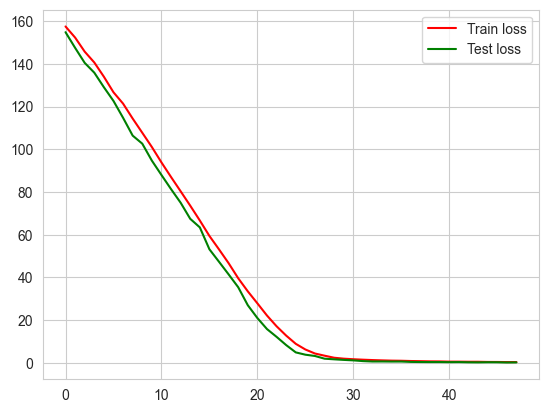

In [111]:
plt.plot(train_loss_list, 'r', label='Train loss')
plt.plot(test_loss_list, 'g', label='Test loss')
plt.legend()   
# plt.ylim(-1,5)

In [76]:
def getNextNRecommendation(model, user_id, n, full_data):
    input_data = transactionDataset(full_data[full_data.customer_id==user_id])
    input_data = DataLoader(dataset=input_data, batch_size=input_data.get_num_item())
    model.eval()
    prediction = []
    for batch in input_data:
        predict = model(*batch[:-1]).to(torch.float64)
        if predict.isnan().sum().item() > 0:
            print('NAN FOUND')
        prediction.extend(nn.Sigmoid()(predict).squeeze(1).tolist())
    purchased_item = full_data[np.logical_and(full_data.customer_id==user_id, full_data.target==1)].product_id.tolist()
    prediction = np.argsort(prediction)
    item_to_recommend = [i for i in prediction if i not in purchased_item]
    return item_to_recommend[::-1][:n]

In [77]:
# getNextNRecommendation(best_rcsys,1,5,user_item_table)

### Simulating the Data Updates

In [78]:
def getTimePartitionDate(data, partition_ratio):
    split_at = round(partition_ratio*len(user_item_table[user_item_table.quantity>0]))
    zeros = data[data.quantity==0]
    current = data[data.quantity>0].sort_values('day')[:split_at]
    future = data[data.quantity>0].sort_values('day')[split_at:]
    future_zeros = future.copy()
    future_zeros['quantity'] = 0
    future_zeros['target'] = 0
    current = pd.concat([current, future_zeros, zeros])
    return current, future

In [79]:
def recallAtK(model,current,future,k):
    predict = 0
    actual = 0
    positive = 0
    for j in future.customer_id.unique():
        product_id_list = set(future[future.customer_id==j].product_id.tolist())
        predicted_product_id_list = set(getNextNRecommendation(model,j,k,current))
        actual += len(product_id_list)
        positive += len(predicted_product_id_list)
        predict += len(product_id_list & predicted_product_id_list)
    print('actual positive', actual,'predicted positive',positive,'true prediction', predict)
    return predict/actual

In [80]:
def precisionAtK(model,current,future,k):
    predict = 0
    positive = 0
    for j in future.customer_id.unique():
        product_id_list = set(future[future.customer_id==j].product_id.tolist())
        predicted_product_id_list = set(getNextNRecommendation(model,j,k,current))
        positive += len(predicted_product_id_list)
        predict += len(product_id_list & predicted_product_id_list)
    return predict/positive

In [100]:
current, future = getTimePartitionDate(user_item_table,0.95)

In [101]:
train_current, test_current, val_current = train_tet_val_split(current)
train_loader_current = DataLoader(dataset=train_current, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader_current = DataLoader(dataset=test_current, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader_current = DataLoader(dataset=val_current, batch_size=batch_size, shuffle=True, drop_last=True)

In [102]:
# DCN with recall@k
rcsys = RecSys(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(rcsys.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = RMSELoss()
cur_train_loss_list, cur_test_loss_list = trainModel(num_epoch, 
    rcsys, loss_function, train_loader_current, test_loader_current, optimizer, patience=3, clip_threshold=0.2, 
    save_model_name='best_current_model_95', recallatKinputs={'current': current,'future': future,'k': 10})

---------Start Training---------
Epoch: 0 Train loss: 5.988436408927385 Test loss: 0.09539087772245364
--------------------------------------
actual positive 919 predicted positive 8070 true prediction 155
Recall@10:  0.16866158868335146
Precision@10:  0.019206939281288724
--------------------------------------
Epoch: 1 Train loss: 0.05412738561535491 Test loss: 0.14462033990098863
--------------------------------------
actual positive 919 predicted positive 8070 true prediction 151
Recall@10:  0.16430903155603918
Precision@10:  0.018711276332094177
--------------------------------------
Epoch: 2 Train loss: 0.04271018423098603 Test loss: 0.16198400125242612
--------------------------------------
actual positive 919 predicted positive 8070 true prediction 159
Recall@10:  0.17301414581066377
Precision@10:  0.01970260223048327
--------------------------------------
Epoch: 3 Train loss: 0.039755202649888424 Test loss: 0.17260221532751507
--------------------------------------
actual posit

In [103]:
# DeepFm with recall@k
rcsys = DeepFM(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(rcsys.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = RMSELoss()
cur_train_loss_list, cur_test_loss_list = trainModel(num_epoch, 
    rcsys, loss_function, train_loader_current, test_loader_current, optimizer, patience=3, clip_threshold=0.2, 
    save_model_name='best_current_model_95_dfm', recallatKinputs={'current': current,'future': future,'k': 10})

---------Start Training---------
Epoch: 0 Train loss: 4.057153934305304 Test loss: 0.07856932723113592
--------------------------------------
actual positive 919 predicted positive 8070 true prediction 153
Recall@10:  0.16648531011969533
Precision@10:  0.01895910780669145
--------------------------------------
Epoch: 1 Train loss: 0.061787249258768245 Test loss: 0.15186883071571242
--------------------------------------
actual positive 919 predicted positive 8070 true prediction 163
Recall@10:  0.17736670293797607
Precision@10:  0.020198265179677818
--------------------------------------
Epoch: 2 Train loss: 0.04432281327253536 Test loss: 0.16939712405162963
--------------------------------------
actual positive 919 predicted positive 8070 true prediction 162
Recall@10:  0.176278563656148
Precision@10:  0.020074349442379184
--------------------------------------
Epoch: 3 Train loss: 0.04136486493947956 Test loss: 0.1678442300426967
--------------------------------------
actual positive

In [104]:
best_rcsys_current = RecSys(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(best_rcsys_current.parameters(), lr=0.0001, weight_decay=0.0001)

best_current_model_checkpoint = torch.load(model_path+'/best_current_model_95.pth')
best_rcsys_current.load_state_dict(best_current_model_checkpoint['model'])
optimizer.load_state_dict(best_current_model_checkpoint['optimizer'])
best_epoch = best_current_model_checkpoint['epoch']

In [105]:
for i in [5,10,15,20]:
    print('K = ', i, 'Recall@K = ', recallAtK(best_rcsys_current,current,future,i))
for i in [5,10,15,20]:
    print('K = ', i, 'Precision@K = ', precisionAtK(best_rcsys_current,current,future,i))

actual positive 919 predicted positive 4035 true prediction 109
K =  5 Recall@K =  0.11860718171926006
actual positive 919 predicted positive 8070 true prediction 155
K =  10 Recall@K =  0.16866158868335146
actual positive 919 predicted positive 12105 true prediction 205
K =  15 Recall@K =  0.22306855277475518
actual positive 919 predicted positive 16140 true prediction 258
K =  20 Recall@K =  0.2807399347116431
K =  5 Precision@K =  0.02701363073110285
K =  10 Precision@K =  0.019206939281288724
K =  15 Precision@K =  0.016935150764147047
K =  20 Precision@K =  0.015985130111524165


In [106]:
best_deepfm_current = DeepFM(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(best_deepfm_current.parameters(), lr=0.0001, weight_decay=0.0001)

best_current_model_checkpoint = torch.load(model_path+'/best_current_model_95_dfm.pth')
best_deepfm_current.load_state_dict(best_current_model_checkpoint['model'])
optimizer.load_state_dict(best_current_model_checkpoint['optimizer'])
best_epoch = best_current_model_checkpoint['epoch']

In [107]:
for i in [5,10,15,20]:
    print('K = ', i, 'Recall@K = ', recallAtK(best_deepfm_current,current,future,i))
for i in [5,10,15,20]:
    print('K = ', i, 'Precision@K = ', precisionAtK(best_deepfm_current,current,future,i))

actual positive 919 predicted positive 4035 true prediction 109
K =  5 Recall@K =  0.11860718171926006
actual positive 919 predicted positive 8070 true prediction 153
K =  10 Recall@K =  0.16648531011969533
actual positive 919 predicted positive 12105 true prediction 193
K =  15 Recall@K =  0.2100108813928183
actual positive 919 predicted positive 16140 true prediction 235
K =  20 Recall@K =  0.25571273122959737
K =  5 Precision@K =  0.02701363073110285
K =  10 Precision@K =  0.01895910780669145
K =  15 Precision@K =  0.01594382486575795
K =  20 Precision@K =  0.014560099132589838


In [95]:
# with different time split - 85%
current, future = getTimePartitionDate(user_item_table,0.85)
train_current, test_current, val_current = train_tet_val_split(current)
train_loader_current = DataLoader(dataset=train_current, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader_current = DataLoader(dataset=test_current, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader_current = DataLoader(dataset=val_current, batch_size=batch_size, shuffle=True, drop_last=True)

rcsys = RecSys(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(rcsys.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = RMSELoss()
cur_train_loss_list, cur_test_loss_list = trainModel(num_epoch, 
    rcsys, loss_function, train_loader_current, test_loader_current, optimizer, patience=3, clip_threshold=0.2, 
    save_model_name='best_current_model_85', recallatKinputs={'current': current,'future': future,'k': 10})

---------Start Training---------
Epoch: 0 Train loss: 0.2000144485592612 Test loss: 0.11033004329801568
--------------------------------------
actual positive 2758 predicted positive 18900 true prediction 427
Recall@10:  0.1548223350253807
Precision@10:  0.02259259259259259
--------------------------------------
Epoch: 1 Train loss: 0.07210002554689439 Test loss: 0.14890241736862217
--------------------------------------
actual positive 2758 predicted positive 18900 true prediction 454
Recall@10:  0.1646120377084844
Precision@10:  0.02402116402116402
--------------------------------------
Epoch: 2 Train loss: 0.055494109581312324 Test loss: 0.15722388572706583
--------------------------------------
actual positive 2758 predicted positive 18900 true prediction 453
Recall@10:  0.16424945612762873
Precision@10:  0.02396825396825397
--------------------------------------
Epoch: 3 Train loss: 0.05079415021297868 Test loss: 0.16040359350879063
--------------------------------------
actual po

In [96]:
rcsys = DeepFM(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(rcsys.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = RMSELoss()
cur_train_loss_list, cur_test_loss_list = trainModel(num_epoch, 
    rcsys, loss_function, train_loader_current, test_loader_current, optimizer, patience=3, clip_threshold=0.2, 
     save_model_name='best_current_model_85_dfm', recallatKinputs={'current': current,'future': future,'k': 10})

---------Start Training---------
Epoch: 0 Train loss: 8.1110590827514 Test loss: 0.07223625788752083
--------------------------------------
actual positive 2758 predicted positive 18900 true prediction 457
Recall@10:  0.1656997824510515
Precision@10:  0.02417989417989418
--------------------------------------
Epoch: 1 Train loss: 0.07079955685953475 Test loss: 0.1337175570679722
--------------------------------------
actual positive 2758 predicted positive 18900 true prediction 442
Recall@10:  0.1602610587382161
Precision@10:  0.023386243386243386
--------------------------------------
Epoch: 2 Train loss: 0.06075484242233687 Test loss: 0.13458975501504264
--------------------------------------
actual positive 2758 predicted positive 18900 true prediction 478
Recall@10:  0.17331399564902103
Precision@10:  0.02529100529100529
--------------------------------------
Epoch: 3 Train loss: 0.058284075990442795 Test loss: 0.14753264960334123
--------------------------------------
actual posit

In [97]:
# with different time split - 99%
current, future = getTimePartitionDate(user_item_table,0.99)
train_current, test_current, val_current = train_tet_val_split(current)
train_loader_current = DataLoader(dataset=train_current, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader_current = DataLoader(dataset=test_current, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader_current = DataLoader(dataset=val_current, batch_size=batch_size, shuffle=True, drop_last=True)

rcsys = RecSys(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(rcsys.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = RMSELoss()
cur_train_loss_list, cur_test_loss_list = trainModel(num_epoch, 
    rcsys, loss_function, train_loader_current, test_loader_current, optimizer, patience=3, clip_threshold=0.2, 
    save_model_name='best_current_model_85', recallatKinputs={'current': current,'future': future,'k': 10})

---------Start Training---------
Epoch: 0 Train loss: 13.853441296623375 Test loss: 0.05545034859655792
--------------------------------------
actual positive 184 predicted positive 1820 true prediction 24
Recall@10:  0.13043478260869565
Precision@10:  0.013186813186813187
--------------------------------------
Epoch: 1 Train loss: 0.06528403355787729 Test loss: 0.10024344599817485
--------------------------------------
actual positive 184 predicted positive 1820 true prediction 27
Recall@10:  0.14673913043478262
Precision@10:  0.014835164835164835
--------------------------------------
Epoch: 2 Train loss: 0.04638210476452937 Test loss: 0.11109546533214722
--------------------------------------
actual positive 184 predicted positive 1820 true prediction 28
Recall@10:  0.15217391304347827
Precision@10:  0.015384615384615385
--------------------------------------
Epoch: 3 Train loss: 0.03649774526175011 Test loss: 0.13329322975689628
--------------------------------------
actual positiv

In [98]:
rcsys = DeepFM(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(rcsys.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = RMSELoss()
cur_train_loss_list, cur_test_loss_list = trainModel(num_epoch, 
    rcsys, loss_function, train_loader_current, test_loader_current, optimizer, patience=3, clip_threshold=0.2, 
     save_model_name='best_current_model_85_dfm', recallatKinputs={'current': current,'future': future,'k': 10})

---------Start Training---------
Epoch: 0 Train loss: 7.117046254405069 Test loss: 0.09873548071257261
--------------------------------------
actual positive 184 predicted positive 1820 true prediction 27
Recall@10:  0.14673913043478262
Precision@10:  0.014835164835164835
--------------------------------------
Epoch: 1 Train loss: 0.04720922146330431 Test loss: 0.12752537271484782
--------------------------------------
actual positive 184 predicted positive 1820 true prediction 26
Recall@10:  0.14130434782608695
Precision@10:  0.014285714285714285
--------------------------------------
Epoch: 2 Train loss: 0.03755514346329801 Test loss: 0.14728597845092092
--------------------------------------
actual positive 184 predicted positive 1820 true prediction 28
Recall@10:  0.15217391304347827
Precision@10:  0.015384615384615385
--------------------------------------
Epoch: 3 Train loss: 0.035309940384551444 Test loss: 0.1536792542559863
--------------------------------------
actual positive

In [108]:
# Summary recall and precision at 10
# Quantity Prediction
# ----------------------------------------------------------
#   Model |Split|     Recall@10      |     Precission@10
# ----------------------------------------------------------
#   DCN   | 95  |0.16866158868335146 | 0.019206939281288724
# ----------------------------------------------------------
#   DFM   | 95  |0.16648531011969533 | 0.01895910780669145
# ----------------------------------------------------------
#   DCN   | 85  |0.1548223350253807  | 0.02259259259259259
# ----------------------------------------------------------
#   DFM   | 85  |0.1656997824510515  | 0.02417989417989418
# ----------------------------------------------------------
#   DCN   | 99  |0.13043478260869565 | 0.013186813186813187
# ----------------------------------------------------------
#   DFM   | 99  |0.14673913043478262 | 0.014835164835164835
# ----------------------------------------------------------